# Villa Itatí — Modos de habitar, movilidades y sociabilidades

### Análisis exploratorio de una matriz cualitativa construida a partir de entrevistas

**Proyecto:** Informe Itatí — Sociología UBA 2025  
**Trabajo de campo:** Villa Itatí, Quilmes, 2024  
**Casos analizados:** 8 entrevistas  
**Herramientas:** Python, Pandas, Matplotlib

## Objetivo

Este notebook explora una matriz analítica construida a partir del grillado y sistematización de entrevistas. El objetivo no es cuantificar artificialmente categorías cualitativas, sino observar relaciones entre **movilidades cotidianas, sociabilidades, expectativas, representaciones y estados de movilidad**.

La matriz constituye una capa intermedia entre el trabajo de campo y la interpretación sociológica: las categorías fueron construidas en el proceso de investigación y posteriormente estructuradas para permitir análisis reproducibles.

> **Nota metodológica:** los valores `NA` representan información que todavía no fue incorporada a esta versión de la matriz. No se imputan datos por inferencia.

## 1. Pregunta de análisis

> **¿Cómo se articulan las movilidades cotidianas, las redes de sociabilidad y las expectativas de permanencia en diferentes modos de habitar Villa Itatí?**

La investigación trabaja estas dimensiones en diálogo con las representaciones de sí y del barrio, y sintetiza sus relaciones mediante distintos estados de movilidad.

## 2. Flujo de construcción del dato

```text
Entrevistas
    ↓
Grillado / codificación
    ↓
Categorías analíticas
    ↓
Matriz maestra
    ↓
Análisis exploratorio en Python
    ↓
Visualización + interpretación sociológica
```

La programación funciona aquí como una herramienta para **estructurar, controlar, explorar y visualizar** los datos construidos durante la investigación.

## 3. Carga de datos

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Si ejecutás el notebook desde el repositorio, colocá el CSV en data/
DATA_PATH = Path('../data/itati_matriz_maestra_v1.csv')

df = pd.read_csv(DATA_PATH)
df.head()

,ID,genero,edad,grupo_etario,anios_residencia,nivel_educativo,condicion_actividad,ocupacion,composicion_hogar,movilidad_cotidiana,zonas_valorizadas,representacion_jovenes,sociabilidad_directa,sociabilidad_indirecta,expectativa_para_si,expectativa_para_barrio,expectativa_para_jovenes,representacion_de_si,representacion_del_barrio,estado_movilidad,ede_espera,ede_esperanza,ede_resignacion,ede_hacedor,ede_transmision
0,ORI,mujer,23.0,joven,NaN,NaN,NaN,trabajadora social,"abuela, madre, hermanos y sobrinos",Inm.F. de carácter barrial,La Cava: peligrosa; zonas de comedores/apoyos: solidarias y comunitarias,Preocupación por jóvenes que no participan del apoyo escolar; sostiene incentivos desde Centro d...,Trabajo y familia,NaN,Quedarse con proyección de mejora,NaN,NaN,Sostenedora de hogar,Comunitario pero peligroso,EdeH + EdeEz,0,1,0,1,NaN
1,VAN,mujer,25.0,joven,NaN,NaN,NaN,coordinadora en ETIS,NaN,Inm.F. de carácter barrial,NaN,Resignación ante jóvenes que priorizan el celular frente al apoyo escolar,Familiar,NaN,"Estudiar, aunque prioriza familia en el barrio",NaN,NaN,Cuidadora,Desidia de vecinos y No Estado,EdeH + EdeR,0,0,1,1,NaN
2,MAT,varón,21.0,joven,NaN,NaN,NaN,mozo en Olivos,pareja; espera un hijo,Mov. obligada,Barrio caminable/tranquilo; zona de la laguna asociada a presencia policial,Lectura centrada en autonomía/protección; quienes se pierden requieren intervención externa,Amigos y familia,NaN,Construir comunidad a su hija,NaN,NaN,Protector y autónomo,No Estado y ayuda de contención de vecinos,EdeH + EdeR,0,0,1,1,NaN
3,MAR,varón,19.0,joven,NaN,NaN,NaN,tutor en ETIS y profesor de bachata,amigos; mantiene apoyo económico del padre,Inm.F. de carácter barrial,NaN,NaN,Amigos y referentes,NaN,Irse a alquilar con un amigo fuera del barrio,NaN,NaN,Tutor,Desidia de vecinos y No Estado pero con red,EdeH + EdeR,0,0,1,1,NaN
4,CEC,mujer,64.0,adulta,59.0,sexto año (sistema anterior),NaN,maestranza/limpieza en salud municipal,"esposo, nietos e hijo",Movilidad de cuidado,Barrio más denso/encerrado por crecimiento constructivo; pérdida de espacios,NaN,Familia e Iglesia,NaN,Lugar para las nietas,NaN,NaN,Cuidadora-protectora,Fragmentado a la espera de mejor gobierno,EdeH + EdeEz,0,1,0,1,NaN


## 4. Estructura y control de calidad

Antes de analizar, verificamos dimensiones, tipos de variables y datos faltantes. En una matriz derivada de investigación cualitativa, los faltantes no deben interpretarse automáticamente como ausencia del fenómeno.

In [2]:
print(f'Casos: {df.shape[0]}')
print(f'Variables: {df.shape[1]}')

df.info()

Casos: 8
Variables: 25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         8 non-null      object 
 1   genero                     8 non-null      object 
 2   edad                       8 non-null      float64
 3   grupo_etario               8 non-null      object 
 4   anios_residencia           2 non-null      float64
 5   nivel_educativo            2 non-null      object 
 6   condicion_actividad        0 non-null      float64
 7   ocupacion                  8 non-null      object 
 8   composicion_hogar          7 non-null      object 
 9   movilidad_cotidiana        8 non-null      object 
 10  zonas_valorizadas          3 non-null      object 
 11  representacion_jovenes     3 non-null      object 
 12  sociabilidad_directa       8 non-null      object 
 13  sociabilidad_indirecta     0 no

In [3]:
# Cantidad y porcentaje de valores faltantes por variable
missing = pd.DataFrame({
    'missing_n': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(1)
}).sort_values('missing_pct', ascending=False)

missing

,missing_n,missing_pct
condicion_actividad,8,100.0
ede_transmision,8,100.0
sociabilidad_indirecta,8,100.0
expectativa_para_jovenes,8,100.0
expectativa_para_barrio,8,100.0
nivel_educativo,6,75.0
anios_residencia,6,75.0
zonas_valorizadas,5,62.5
representacion_jovenes,5,62.5
composicion_hogar,1,12.5


### Criterio de lectura

La presencia de `NA` en esta versión indica que la variable todavía no fue incorporada o sistematizada para ese caso. No equivale necesariamente a que la entrevista no contenga información sobre el tema.

## 5. Perfil de la matriz

La primera exploración se concentra en las variables categoriales que ya están completas en el Cuadro B.

In [4]:
for col in ['movilidad_cotidiana', 'sociabilidad_directa', 'expectativa_para_si', 'estado_movilidad']:
    print(f'\n--- {col} ---')
    display(df[col].value_counts(dropna=False))


--- movilidad_cotidiana ---


movilidad_cotidiana
Inm.F. de carácter barrial    3
Mov. obligada                 2
Movilidad de cuidado          1
Mov. obligada de cuidado      1
Inm. F. por discapacidad      1
Name: count, dtype: int64


--- sociabilidad_directa ---


sociabilidad_directa
Trabajo y familia               1
Familiar                        1
Amigos y familia                1
Amigos y referentes             1
Familia e Iglesia               1
Familia, referentes y amigos    1
Familia                         1
Familia y vecinos íntimos       1
Name: count, dtype: int64


--- expectativa_para_si ---


expectativa_para_si
Quedarse con proyección de mejora                    1
Estudiar, aunque prioriza familia en el barrio       1
Construir comunidad a su hija                        1
Irse a alquilar con un amigo fuera del barrio        1
Lugar para las nietas                                1
Aspirar a mudarse                                    1
Esperar su pensión y seguir trabajando en su casa    1
Esperar urbanización para su gente                   1
Name: count, dtype: int64


--- estado_movilidad ---


estado_movilidad
EdeH + EdeEz    3
EdeH + EdeR     3
EdeE + EdeR     2
Name: count, dtype: int64

## Perfil de los casos

La matriz incorpora variables sociodemográficas únicamente cuando están explícitamente documentadas en los materiales de investigación. Los campos sin respaldo suficiente permanecen como `NA`.


In [5]:
profile_cols = ['ID','genero','edad','grupo_etario','anios_residencia','ocupacion','composicion_hogar']
display(df[profile_cols])


,ID,genero,edad,grupo_etario,anios_residencia,ocupacion,composicion_hogar
0,ORI,mujer,23.0,joven,NaN,trabajadora social,"abuela, madre, hermanos y sobrinos"
1,VAN,mujer,25.0,joven,NaN,coordinadora en ETIS,NaN
2,MAT,varón,21.0,joven,NaN,mozo en Olivos,pareja; espera un hijo
3,MAR,varón,19.0,joven,NaN,tutor en ETIS y profesor de bachata,amigos; mantiene apoyo económico del padre
4,CEC,mujer,64.0,adulta,59.0,maestranza/limpieza en salud municipal,"esposo, nietos e hijo"
5,ANA,mujer,34.0,adulta,NaN,profesora de Educación Física; trabajo en ETIS,pareja y dos hijos
6,SER,varón,64.0,adulto,NaN,"panadero; actualmente sin actividad por accidente, espera pensión","esposa, hijos y hermano"
7,JAV,varón,48.0,adulto,48.0,recolector de residuos en Quilmes Centro,esposa e hija


In [6]:
profile_counts = pd.crosstab(df['grupo_etario'], df['genero'])
display(profile_counts)


genero,mujer,varón
grupo_etario,,
adulta,2,0
adulto,0,2
joven,2,2


## 6. Movilidades cotidianas

Se observa cómo se distribuyen los tipos de movilidad construidos durante el análisis cualitativo. Las categorías se mantienen con su denominación original para preservar la trazabilidad con el informe.

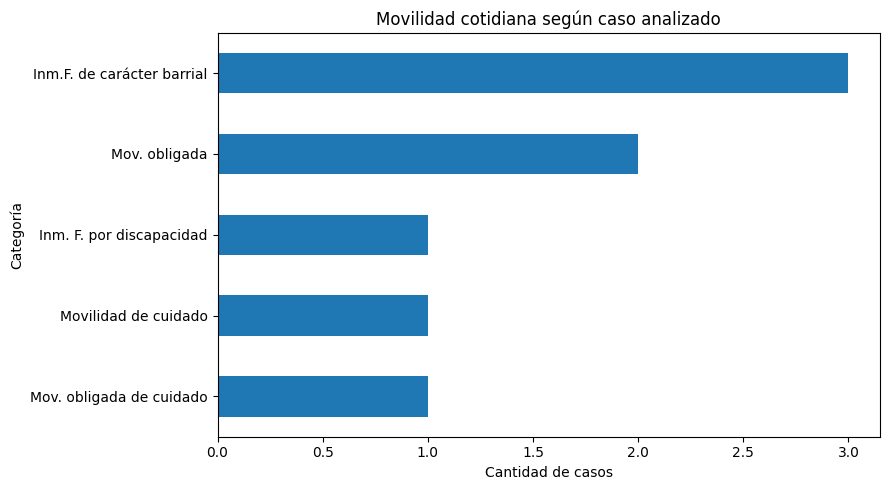

In [7]:
mobility_counts = df['movilidad_cotidiana'].value_counts().sort_values()

ax = mobility_counts.plot(kind='barh', figsize=(9, 5))
ax.set_title('Movilidad cotidiana según caso analizado')
ax.set_xlabel('Cantidad de casos')
ax.set_ylabel('Categoría')
plt.tight_layout()
plt.show()

## 7. Sociabilidades

La variable `sociabilidad_directa` resume los vínculos que aparecen como recursos, apoyos o estrategias relevantes en el Cuadro B.

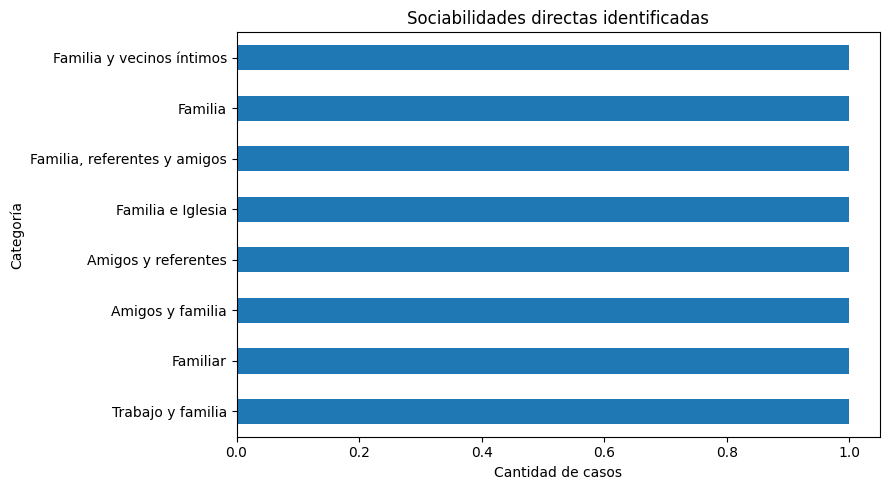

In [8]:
sociability_counts = df['sociabilidad_directa'].value_counts().sort_values()

ax = sociability_counts.plot(kind='barh', figsize=(9, 5))
ax.set_title('Sociabilidades directas identificadas')
ax.set_xlabel('Cantidad de casos')
ax.set_ylabel('Categoría')
plt.tight_layout()
plt.show()

## 8. Estados de movilidad

Los estados de movilidad son categorías teóricas multietiqueta. Por eso se utilizan indicadores binarios auxiliares para explorar su presencia en los casos.

**Importante:** estos indicadores no constituyen una escala de mayor/menor movilidad. En esta versión, EdeT aparece en el modelo teórico pero todavía no tiene casos codificados, por lo que se excluye del gráfico de frecuencias.

In [9]:
state_cols = [
    'ede_espera', 'ede_esperanza', 'ede_resignacion',
    'ede_hacedor', 'ede_transmision'
]

state_labels = {
    'ede_espera': 'EdeE — Espera',
    'ede_esperanza': 'EdeEz — Esperanza',
    'ede_resignacion': 'EdeR — Resignación',
    'ede_hacedor': 'EdeH — Hacedor',
    'ede_transmision': 'EdeT — Transmisión'
}


In [10]:
# Se cuentan solo los estados que ya tienen al menos un caso codificado.
available_state_cols = [c for c in state_cols if df[c].notna().any()]

state_counts = df[available_state_cols].sum(min_count=1).rename(index=state_labels).sort_values()
state_counts

EdeE — Espera         2
EdeEz — Esperanza     3
EdeR — Resignación    5
EdeH — Hacedor        6
dtype: int64

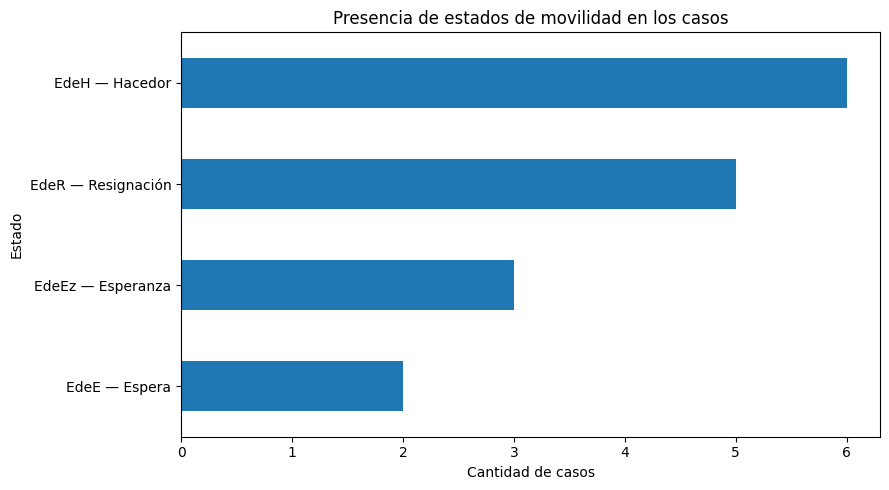

In [11]:
ax = state_counts.plot(kind='barh', figsize=(9, 5))
ax.set_title('Presencia de estados de movilidad en los casos')
ax.set_xlabel('Cantidad de casos')
ax.set_ylabel('Estado')
plt.tight_layout()
plt.show()

## 9. Matriz de casos × estados

Esta representación permite observar la combinación de estados de cada caso sin imponer una jerarquía entre ellos.

In [12]:
state_matrix = df.set_index('ID')[state_cols].rename(columns=state_labels)
state_matrix

,EdeE — Espera,EdeEz — Esperanza,EdeR — Resignación,EdeH — Hacedor,EdeT — Transmisión
ID,,,,,
ORI,0,1,0,1,NaN
VAN,0,0,1,1,NaN
MAT,0,0,1,1,NaN
MAR,0,0,1,1,NaN
CEC,0,1,0,1,NaN
ANA,0,1,0,1,NaN
SER,1,0,1,0,NaN
JAV,1,0,1,0,NaN


## 10. Movilidad y estado de movilidad

Este cruce permite explorar cómo se relacionan las categorías empíricas de movilidad cotidiana con la síntesis teórica de estados de movilidad.

In [13]:
mobility_state = pd.crosstab(
    df['movilidad_cotidiana'],
    df['estado_movilidad']
)

mobility_state

estado_movilidad,EdeE + EdeR,EdeH + EdeEz,EdeH + EdeR
movilidad_cotidiana,,,
Inm. F. por discapacidad,1,0,0
Inm.F. de carácter barrial,0,1,2
Mov. obligada,1,0,1
Mov. obligada de cuidado,0,1,0
Movilidad de cuidado,0,1,0


## 11. Sociabilidad y estado de movilidad

El siguiente cruce permite observar si determinados tipos de vínculos aparecen asociados a determinadas combinaciones de estados. Debido al tamaño reducido de la matriz, se trata de una **exploración descriptiva**, no de una prueba estadística de asociación.

In [14]:
sociability_state = pd.crosstab(
    df['sociabilidad_directa'],
    df['estado_movilidad']
)

sociability_state

estado_movilidad,EdeE + EdeR,EdeH + EdeEz,EdeH + EdeR
sociabilidad_directa,,,
Amigos y familia,0,0,1
Amigos y referentes,0,0,1
Familia,1,0,0
Familia e Iglesia,0,1,0
Familia y vecinos íntimos,1,0,0
"Familia, referentes y amigos",0,1,0
Familiar,0,0,1
Trabajo y familia,0,1,0


## 12. Mapa conceptual del análisis

```text
                 MOVILIDADES
                ↙          ↘
               ↙            ↘
      SOCIABILIDADES  ←→  EXPECTATIVAS
               ↘            ↙
                ↘          ↙
             REPRESENTACIONES
                    │
                    ▼
             MODO DE HABITAR
                    │
                    ▼
             ESTADO DE MOVILIDAD
```

El esquema debe leerse como una articulación analítica y no como un modelo causal.

## 13. Exportación de tablas para el portfolio

Las tablas generadas pueden exportarse para reutilizarlas en visualizaciones o en otros documentos.

In [15]:
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

state_matrix.to_csv(OUTPUT_DIR / 'estados_movilidad.csv', encoding='utf-8-sig')
mobility_state.to_csv(OUTPUT_DIR / 'movilidad_estado.csv', encoding='utf-8-sig')
sociability_state.to_csv(OUTPUT_DIR / 'sociabilidad_estado.csv', encoding='utf-8-sig')

print('Tablas exportadas en:', OUTPUT_DIR.resolve())

Tablas exportadas en: /mnt/data/itati-modos-de-habitar/outputs


## 14. Límites y próximos pasos

Esta primera versión trabaja con una matriz de **8 casos** y, por lo tanto, sus resultados son exploratorios. El valor analítico del proyecto no reside en generalizar estadísticamente los patrones observados, sino en hacer visible y reproducible el proceso mediante el cual categorías cualitativas fueron construidas y relacionadas.

### Próximas etapas

- Completar las variables todavía pendientes a partir de los materiales originales.
- Incorporar las zonas valorizadas y representaciones territoriales.
- Construir visualizaciones de relaciones entre dimensiones.
- Evaluar una representación de red entre casos, vínculos y categorías.
- Incorporar, si resulta metodológicamente pertinente, una capa territorial/GIS.
- Preparar una versión pública anonimizada para GitHub.

### Principio de reproducibilidad

La matriz pública debe contener únicamente información autorizada y anonimizada. Las entrevistas originales y cualquier información sensible deben permanecer fuera del repositorio público salvo que exista autorización explícita para compartirlas.

## Referencias de trabajo

- Sasso, Facundo Gastón. *Informe Itatí*. Sociología, UBA, 2025.
- Sasso, Facundo Gastón. *El cuidado en clave urbana. Una mirada del barrio Villa Itatí, partido de Quilmes, Argentina, y sus modos de habitar la periferia*. 2026.

Las categorías utilizadas en este notebook provienen de la matriz de trabajo y de los cuadros analíticos desarrollados en la investigación.